# Face Verification with Siamese Networks on LFW

In [1]:
import os, random, itertools, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, f1_score
import pandas as pd

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import img_to_array

import kagglehub

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download LFW
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


# Data Engineering: Parse, Filter

LFW root resolved to: /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Total identities found : 5749
Total images           : 13233

After filtering (≥12 imgs/person):
  Identities : 127
  Images     : 3998


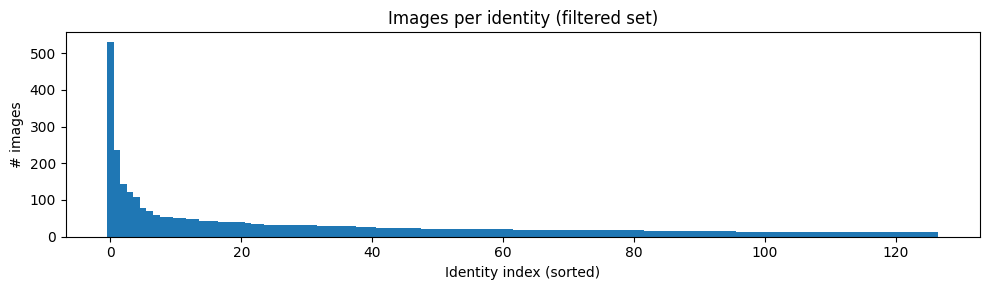

In [2]:
DATA_ROOT = None
for root, dirs, files in os.walk(path):
    if any(Path(root, d, ).is_dir() and len(list(Path(root, d).glob('*.jpg'))) > 0
           for d in dirs):
        DATA_ROOT = Path(root)
        break

print(f"LFW root resolved to: {DATA_ROOT}")
assert DATA_ROOT is not None, "Could not locate LFW person directories — check path structure."

# Parse folder structure
person_to_imgs = defaultdict(list)
for person_dir in sorted(DATA_ROOT.iterdir()):
    if person_dir.is_dir():
        imgs = sorted(person_dir.glob('*.jpg'))
        if imgs:
            person_to_imgs[person_dir.name] = [str(p) for p in imgs]

print(f"Total identities found : {len(person_to_imgs)}")
print(f"Total images           : {sum(len(v) for v in person_to_imgs.values())}")

# Filtering

MIN_IMAGES  = 12
IMG_SIZE    = (105, 105)

filtered = {p: imgs for p, imgs in person_to_imgs.items() if len(imgs) >= MIN_IMAGES}

print(f"\nAfter filtering (≥{MIN_IMAGES} imgs/person):")
print(f"  Identities : {len(filtered)}")
print(f"  Images     : {sum(len(v) for v in filtered.values())}")

# Distribution insight
counts = sorted([len(v) for v in filtered.values()], reverse=True)
plt.figure(figsize=(10,3))
plt.bar(range(len(counts)), counts, width=1.0)
plt.xlabel('Identity index (sorted)'); plt.ylabel('# images')
plt.title('Images per identity (filtered set)')
plt.tight_layout(); plt.show()

persons = list(filtered.keys())

Why filtering?


*   We keep only identities with ≥ MIN_IMAGES images.
*   Fewer images → only trivially-easy positive pairs (same lighting/pose), which causes the network to overfit on superficial cues.


*   MIN_IMAGES=10 gives enough intra-class variety while keeping ~1000+ identities.







#Image Loading Utility


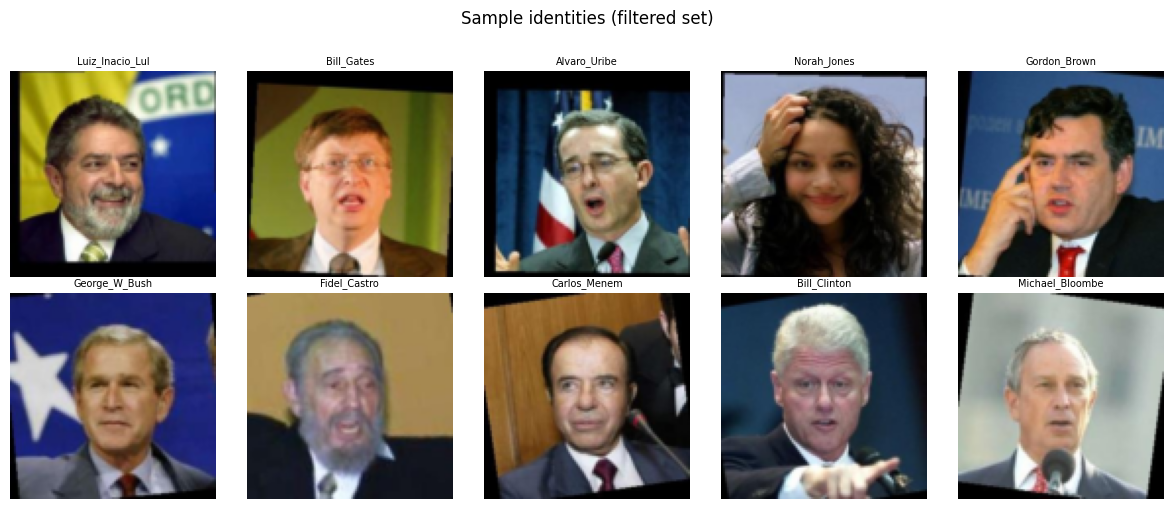

In [3]:
def load_image(path: str, size=IMG_SIZE) -> np.ndarray:
    #Load, resize to `size`, normalize to [0,1], return float32 array.
    img = Image.open(path).convert('RGB').resize(size, Image.BILINEAR)
    return img_to_array(img).astype('float32') / 255.0

# Sanity-check a few images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, person in zip(axes.flat, random.sample(persons, 10)):
    ax.imshow(load_image(filtered[person][0]))
    ax.set_title(person[:15], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample identities (filtered set)', y=1.01)
plt.tight_layout(); plt.show()

A single clean loader with RGB conversion and bilinear resize prevents subtle bugs (RGBA PNGs, accidental double-normalisation)

# Train & Validation Split




In [4]:
train_persons, val_persons = train_test_split(persons, test_size=0.2,
                                               random_state=SEED)
print(f"Train identities : {len(train_persons)}")
print(f"Val   identities : {len(val_persons)}")

Train identities : 101
Val   identities : 26


The split took place at the identity level, not at the image level so that the validation set contains completely unseen people. Therefore, harder and more realistic evaluation scenario for face verification.

# Pair Generator

In [5]:
def generate_pairs(person_dict: dict, n_pairs_per_person: int = 15,
                   neg_ratio: float = 1.0) -> tuple:

    pairs_A, pairs_B, labels = [], [], []
    people = list(person_dict.keys())

    for person in people:
        imgs = person_dict[person]
        # Positive pairs
        pos_combos = list(itertools.combinations(imgs, 2))
        sampled_pos = random.sample(pos_combos, min(n_pairs_per_person, len(pos_combos)))
        for a, b in sampled_pos:
            pairs_A.append(load_image(a))
            pairs_B.append(load_image(b))
            labels.append(1)

        # Negative pairs
        n_neg = int(len(sampled_pos) * neg_ratio)
        for _ in range(n_neg):
            neg_person = random.choice([p for p in people if p != person])
            neg_img    = random.choice(person_dict[neg_person])
            anchor_img = random.choice(imgs)
            pairs_A.append(load_image(anchor_img))
            pairs_B.append(load_image(neg_img))
            labels.append(0)

    # Shuffle
    combined = list(zip(pairs_A, pairs_B, labels))
    random.shuffle(combined)
    pairs_A, pairs_B, labels = zip(*combined)
    return (np.array(pairs_A, dtype='float32'),
            np.array(pairs_B, dtype='float32'),
            np.array(labels,  dtype='float32'))

print("Generating training pairs")
train_A, train_B, train_labels = generate_pairs({p: filtered[p] for p in train_persons},
                                                 n_pairs_per_person=20)
print("Generating validation pairs")
val_A,   val_B,   val_labels   = generate_pairs({p: filtered[p] for p in val_persons},
                                                 n_pairs_per_person=15)

print(f"Train pairs : {len(train_labels)}  |  Pos: {train_labels.sum():.0f}  Neg: {(1-train_labels).sum():.0f}")
print(f"Val   pairs : {len(val_labels)  }  |  Pos: {val_labels.sum():.0f}   Neg: {(1-val_labels).sum():.0f}")

Generating training pairs
Generating validation pairs
Train pairs : 4040  |  Pos: 2020  Neg: 2020
Val   pairs : 780  |  Pos: 390   Neg: 390


Triplet Generator

In [6]:
def generate_triplets(person_dict: dict, n_triplets_per_person: int = 20) -> tuple:

    anchors, positives, negatives = [], [], []
    people = list(person_dict.keys())

    for person in people:
        imgs = person_dict[person]
        if len(imgs) < 2:
            continue
        neg_pool = [p for p in people if p != person]

        for _ in range(n_triplets_per_person):
            a_path, p_path = random.sample(imgs, 2)
            neg_person      = random.choice(neg_pool)
            n_path          = random.choice(person_dict[neg_person])

            anchors.append(load_image(a_path))
            positives.append(load_image(p_path))
            negatives.append(load_image(n_path))

    data = list(zip(anchors, positives, negatives))
    random.shuffle(data)
    anchors, positives, negatives = zip(*data)
    return (np.array(anchors,   dtype='float32'),
            np.array(positives, dtype='float32'),
            np.array(negatives, dtype='float32'))

print("Generating training triplets")
tr_A, tr_P, tr_N = generate_triplets({p: filtered[p] for p in train_persons},
                                       n_triplets_per_person=25)
print("Generating validation triplets")
va_A, va_P, va_N = generate_triplets({p: filtered[p] for p in val_persons},
                                       n_triplets_per_person=15)

print(f"Train triplets : {len(tr_A)}")
print(f"Val   triplets : {len(va_A)}")

Generating training triplets
Generating validation triplets
Train triplets : 2525
Val   triplets : 390


# Loss Functions

In [7]:
# Contrastive Loss
def contrastive_loss(y_true, y_pred, margin=1.0):
    """
    y_true: 1 = same class, 0 = different class
    y_pred: Euclidean distance between embeddings
    """
    y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)), y_pred.dtype)
    loss_same = y_true        * K.square(y_pred)
    loss_diff = (1 - y_true)  * K.square(K.maximum(margin - y_pred, 0.0))
    return K.mean(loss_same + loss_diff)

def contrastive_accuracy(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, tf.shape(y_pred)), y_pred.dtype)
    return K.mean(K.equal(y_true, K.cast(y_pred < 0.5, y_true.dtype)))

# Triplet Loss
def triplet_loss_fn(margin=0.4):
    """
    Soft-margin triplet loss. margin=0.4 is empirically strong for face data.
    """
    def loss(y_true, y_pred):
        # y_pred shape: (batch, 3, embedding_dim)
        anchor   = y_pred[:, 0, :]
        positive = y_pred[:, 1, :]
        negative = y_pred[:, 2, :]
        d_pos = K.sum(K.square(anchor - positive), axis=1)
        d_neg = K.sum(K.square(anchor - negative), axis=1)
        return K.mean(K.maximum(d_pos - d_neg + margin, 0.0))
    return loss

def triplet_accuracy(y_true, y_pred):
    anchor   = y_pred[:, 0, :]
    positive = y_pred[:, 1, :]
    negative = y_pred[:, 2, :]
    d_pos = K.sum(K.square(anchor - positive), axis=1)
    d_neg = K.sum(K.square(anchor - negative), axis=1)
    return K.mean(K.cast(d_pos < d_neg, 'float32'))

print("Loss functions defined.")

Loss functions defined.


# Euclidean Distance Layer

In [8]:
def euclidean_distance(vecs):
    x, y = vecs
    return K.sqrt(K.maximum(K.sum(K.square(x - y), axis=1, keepdims=True), K.epsilon()))

def eucl_dist_output_shape(shapes):
    return (shapes[0][0], 1)

# Architecture 1: Custom CNN Backbone

In [9]:
def build_custom_backbone(input_shape=(105, 105, 3), embedding_dim=256):
    """
    Custom CNN designed for face similarity:
    - 4 conv blocks with increasing filters (32→64→128→256)
    - BatchNorm after each conv stabilises training
    - Dropout before the embedding head prevents co-adaptation
    - L2-normalised output → distances live on a unit hypersphere,
      making the margin in contrastive/triplet loss consistent
    """
    inp = layers.Input(shape=input_shape)

    # Block 1 — low-level edges/textures
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.15)(x)

    # Block 2 — mid-level shapes
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.20)(x)

    # Block 3 — semantic facial features
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 4 — high-level identity features
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)   # GAP > Flatten: fewer params, less overfit

    # Embedding head
    x = layers.Dense(embedding_dim, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(embedding_dim)(x)
    x = layers.Lambda(lambda t: K.l2_normalize(t, axis=1))(x)

    return models.Model(inp, x, name='custom_cnn_backbone')

backbone_cnn = build_custom_backbone()
backbone_cnn.summary()

Model: "custom_cnn_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 105, 105, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 105, 105, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 105, 105, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 105, 105, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 105, 105, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 716,576 (2.73 MB)

 Trainable params: 715,168 (2.73 MB)

 Non-trainable params: 1,408 (5.50 KB)

# Architecture 2: EfficientNetB0 Transfer Learning Backbone

In [10]:
def build_efficientnet_backbone(input_shape=(105, 105, 3), embedding_dim=256,
                                 fine_tune_from_layer: int = 150):
    """
    EfficientNetB0 as frozen feature extractor + trainable head.

    Why EfficientNetB0 over MobileNetV2 / ResNet50 / VGG16?
    - EfficientNet compounds width, depth, resolution scaling → best accuracy/param tradeoff.
    - B0 variant: ~5.3M params, runs fast on Colab T4.
    - Pre-trained on ImageNet; face structure (edges, textures, shapes) transfers perfectly.
    - fine_tune_from_layer=150 unfreezes top ~30 layers for domain adaptation.
    """
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'          # built-in global average pooling
    )

    # Phase 1: freeze entire base
    base.trainable = False

    inp = layers.Input(shape=input_shape)
    # EfficientNet expects [0,255] float OR uses its own preprocessing.
    # Since our images are [0,1], rescale:
    x = layers.Rescaling(255.0)(inp)
    x = base(x, training=False)

    # Embedding head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(embedding_dim)(x)
    x = layers.Lambda(lambda t: K.l2_normalize(t, axis=1))(x)

    model = models.Model(inp, x, name='efficientnet_backbone')

    # Phase 2 fine-tuning handle (called later after initial warm-up)
    def unfreeze_for_finetuning():
        base.trainable = True
        for layer in base.layers[:fine_tune_from_layer]:
            layer.trainable = False
        print(f"Unfrozen {sum(1 for l in base.layers if l.trainable)} layers in EfficientNetB0.")

    model.unfreeze = unfreeze_for_finetuning
    return model

backbone_eff = build_efficientnet_backbone()
backbone_eff.summary()

Model: "efficientnet_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 105, 105, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 105, 105, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,836,771 (18.45 MB)

 Trainable params: 787,200 (3.00 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Siamese Model Builder

In [11]:
def build_siamese_contrastive(backbone):
    """Siamese model for contrastive loss: outputs scalar distance."""
    input_shape = backbone.input_shape[1:]
    inp_a = layers.Input(shape=input_shape, name='img_A')
    inp_b = layers.Input(shape=input_shape, name='img_B')

    emb_a = backbone(inp_a)
    emb_b = backbone(inp_b)

    distance = layers.Lambda(euclidean_distance,
                              output_shape=eucl_dist_output_shape,
                              name='euclidean_dist')([emb_a, emb_b])
    return models.Model([inp_a, inp_b], distance, name=f'siamese_contrast_{backbone.name}')


def build_siamese_triplet(backbone):
    """Siamese model for triplet loss: outputs stacked embeddings."""
    input_shape = backbone.input_shape[1:]
    inp_a = layers.Input(shape=input_shape, name='anchor')
    inp_p = layers.Input(shape=input_shape, name='positive')
    inp_n = layers.Input(shape=input_shape, name='negative')

    emb_a = backbone(inp_a)
    emb_p = backbone(inp_p)
    emb_n = backbone(inp_n)

    # Stack along axis=1 → shape (batch, 3, embedding_dim)
    stacked = layers.Lambda(lambda x: K.stack(x, axis=1),
                             name='stacked_embeddings')([emb_a, emb_p, emb_n])
    return models.Model([inp_a, inp_p, inp_n], stacked,
                         name=f'siamese_triplet_{backbone.name}')

print("Siamese model builders ready.")

Siamese model builders ready.


# Training Callbacks

In [12]:
def make_callbacks(model_name: str, patience_lr=5, patience_stop=12):
    return [
        callbacks.ModelCheckpoint(
            f'/content/{model_name}_best.keras',
            monitor='val_loss', save_best_only=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.4, patience=patience_lr,
            min_lr=1e-7, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_stop,
            restore_best_weights=True, verbose=1
        ),
    ]

# Train: Custom CNN + Contrastive Loss

In [13]:
BATCH_SIZE = 32
EPOCHS     = 40

# Fresh backbone for this experiment
backbone_cnn_c = build_custom_backbone()
siamese_cnn_contrastive = build_siamese_contrastive(backbone_cnn_c)

siamese_cnn_contrastive.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=contrastive_loss,
    metrics=[contrastive_accuracy]
)

hist_cnn_c = siamese_cnn_contrastive.fit(
    [train_A, train_B], train_labels,
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('cnn_contrastive'),
    verbose=1
)
print("Done: Custom CNN + Contrastive")

Epoch 1/40
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - contrastive_accuracy: 0.5269 - loss: 0.3153
Epoch 1: val_loss improved from None to 0.44665, saving model to /content/cnn_contrastive_best.keras

Epoch 1: finished saving model to /content/cnn_contrastive_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 56s 242ms/step - contrastive_accuracy: 0.5421 - loss: 0.2668 - val_contrastive_accuracy: 0.4979 - val_loss: 0.4467 - learning_rate: 0.0010
Epoch 2/40
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - contrastive_accuracy: 0.5397 - loss: 0.2515
Epoch 2: val_loss improved from 0.44665 to 0.29027, saving model to /content/cnn_contrastive_best.keras

Epoch 2: finished saving model to /content/cnn_contrastive_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - contrastive_accuracy: 0.5411 - loss: 0.2503 - val_contrastive_accuracy: 0.5250 - val_loss: 0.2903 - learning_rate: 0.0010
Epoch 3/40
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - contrastive_accuracy: 0.5521 - loss: 0.2474
Epoch 3: val_loss di

# Train: Custom CNN + Triplet Loss

In [14]:
backbone_cnn_t = build_custom_backbone()
siamese_cnn_triplet = build_siamese_triplet(backbone_cnn_t)

siamese_cnn_triplet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

dummy_train = np.zeros(len(tr_A))
dummy_val   = np.zeros(len(va_A))

hist_cnn_t = siamese_cnn_triplet.fit(
    [tr_A, tr_P, tr_N], dummy_train,
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    validation_data=([va_A, va_P, va_N], dummy_val),
    callbacks=make_callbacks('cnn_triplet'),
    verbose=1
)
print("Done: Custom CNN + Triplet")

Epoch 1/40
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 0.3992 - triplet_accuracy: 0.5544
Epoch 1: val_loss improved from None to 0.40454, saving model to /content/cnn_triplet_best.keras

Epoch 1: finished saving model to /content/cnn_triplet_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 61s 453ms/step - loss: 0.3866 - triplet_accuracy: 0.5463 - val_loss: 0.4045 - val_triplet_accuracy: 0.5104 - learning_rate: 0.0010
Epoch 2/40
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.3603 - triplet_accuracy: 0.5840
Epoch 2: val_loss improved from 0.40454 to 0.38115, saving model to /content/cnn_triplet_best.keras

Epoch 2: finished saving model to /content/cnn_triplet_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - loss: 0.3612 - triplet_accuracy: 0.5795 - val_loss: 0.3812 - val_triplet_accuracy: 0.5361 - learning_rate: 0.0010
Epoch 3/40
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.3569 - triplet_accuracy: 0.5752
Epoch 3: val_loss improved from 0.38115 to 0.36036, saving model to /co

# Train: EfficientNetB0 + Contrastive Loss

In [15]:
# Warm-up with frozen base
backbone_eff_c = build_efficientnet_backbone()
siamese_eff_contrastive = build_siamese_contrastive(backbone_eff_c)

siamese_eff_contrastive.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=contrastive_loss,
    metrics=[contrastive_accuracy]
)

hist_eff_c_warmup = siamese_eff_contrastive.fit(
    [train_A, train_B], train_labels,
    batch_size=BATCH_SIZE, epochs=15,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('eff_contrastive_warmup'),
    verbose=1
)

#  Fine-tune top layers
backbone_eff_c.unfreeze()
siamese_eff_contrastive.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),   # very low LR to protect pre-trained weights
    loss=contrastive_loss,
    metrics=[contrastive_accuracy]
)

hist_eff_c_ft = siamese_eff_contrastive.fit(
    [train_A, train_B], train_labels,
    batch_size=16,  # smaller batch to fit larger unrolled graph in GPU memory
    epochs=25,
    validation_data=([val_A, val_B], val_labels),
    callbacks=make_callbacks('eff_contrastive_finetune'),
    verbose=1
)
print("Done: EfficientNetB0 + Contrastive")

Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - contrastive_accuracy: 0.5732 - loss: 0.2654
Epoch 1: val_loss improved from None to 0.21347, saving model to /content/eff_contrastive_warmup_best.keras

Epoch 1: finished saving model to /content/eff_contrastive_warmup_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 108s 460ms/step - contrastive_accuracy: 0.6220 - loss: 0.2306 - val_contrastive_accuracy: 0.6750 - val_loss: 0.2135 - learning_rate: 5.0000e-04
Epoch 2/15
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - contrastive_accuracy: 0.7099 - loss: 0.1911
Epoch 2: val_loss improved from 0.21347 to 0.20149, saving model to /content/eff_contrastive_warmup_best.keras

Epoch 2: finished saving model to /content/eff_contrastive_warmup_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - contrastive_accuracy: 0.7185 - loss: 0.1894 - val_contrastive_accuracy: 0.7042 - val_loss: 0.2015 - learning_rate: 5.0000e-04
Epoch 3/15
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - contrastive_accuracy: 0.7420

# Train: EfficientNetB0 + Triplet Loss

In [16]:
backbone_eff_t = build_efficientnet_backbone()
siamese_eff_triplet = build_siamese_triplet(backbone_eff_t)

siamese_eff_triplet.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

hist_eff_t_warmup = siamese_eff_triplet.fit(
    [tr_A, tr_P, tr_N], dummy_train,
    batch_size=BATCH_SIZE, epochs=15,
    validation_data=([va_A, va_P, va_N], dummy_val),
    callbacks=make_callbacks('eff_triplet_warmup'),
    verbose=1
)

backbone_eff_t.unfreeze()
siamese_eff_triplet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=triplet_loss_fn(margin=0.4),
    metrics=[triplet_accuracy]
)

hist_eff_t_ft = siamese_eff_triplet.fit(
    [tr_A, tr_P, tr_N], dummy_train,
    batch_size=16, epochs=25,
    validation_data=([va_A, va_P, va_N], dummy_val),
    callbacks=make_callbacks('eff_triplet_finetune'),
    verbose=1
)
print("Done: EfficientNetB0 + Triplet")

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - loss: 0.2713 - triplet_accuracy: 0.7081
Epoch 1: val_loss improved from None to 0.21546, saving model to /content/eff_triplet_warmup_best.keras

Epoch 1: finished saving model to /content/eff_triplet_warmup_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 133s 941ms/step - loss: 0.2501 - triplet_accuracy: 0.7287 - val_loss: 0.2155 - val_triplet_accuracy: 0.7572 - learning_rate: 5.0000e-04
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1949 - triplet_accuracy: 0.7938
Epoch 2: val_loss improved from 0.21546 to 0.19376, saving model to /content/eff_triplet_warmup_best.keras

Epoch 2: finished saving model to /content/eff_triplet_warmup_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.1888 - triplet_accuracy: 0.7972 - val_loss: 0.1938 - val_triplet_accuracy: 0.7821 - learning_rate: 5.0000e-04
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1611 - triplet_accuracy: 0.8326
Epoch 3: val_loss improved from 0.1937

# Training Curves for all 4 experiments

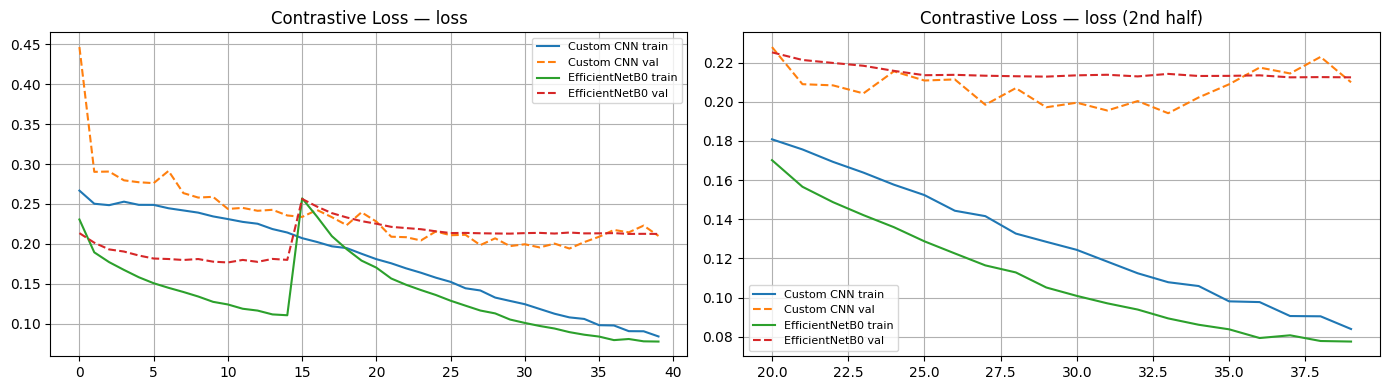

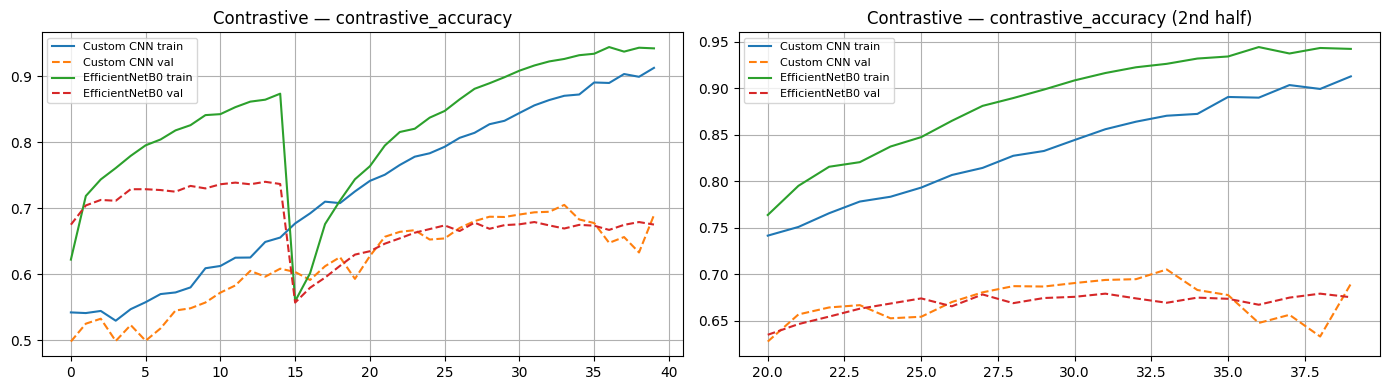

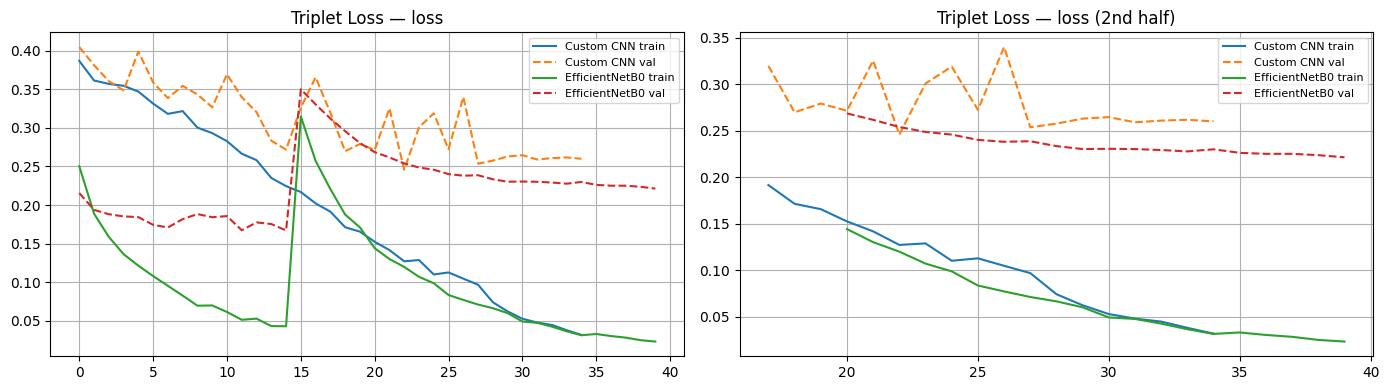

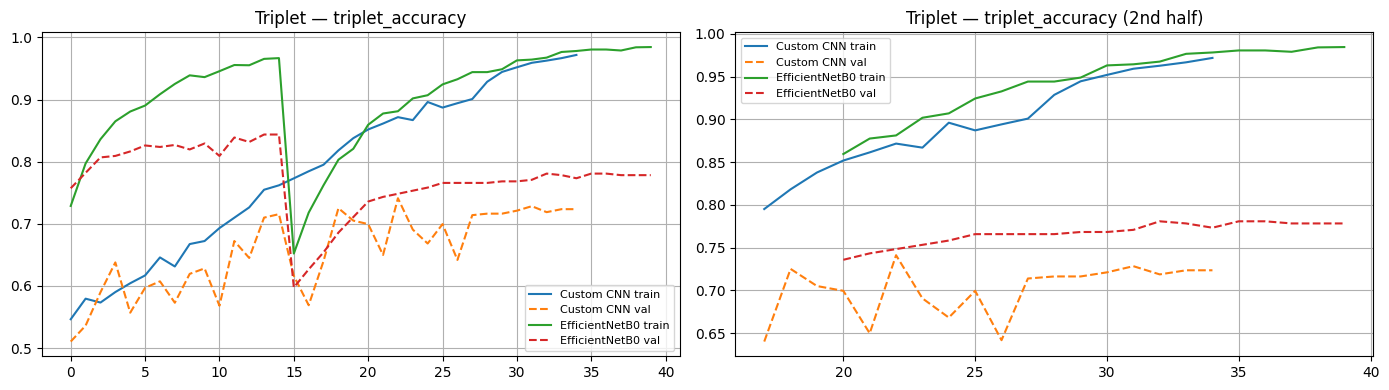

In [17]:
def plot_history(hist_list, labels, metric='loss', title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for hist, lbl in zip(hist_list, labels):
        axes[0].plot(hist.history[metric],        label=f'{lbl} train')
        axes[0].plot(hist.history[f'val_{metric}'], '--', label=f'{lbl} val')
    axes[0].set_title(f'{title} — {metric}'); axes[0].legend(fontsize=8); axes[0].grid(True)

    # Zoom in on last half for clarity
    for hist, lbl in zip(hist_list, labels):
        n = len(hist.history[metric])
        axes[1].plot(range(n//2, n), hist.history[metric][n//2:],        label=f'{lbl} train')
        axes[1].plot(range(n//2, n), hist.history[f'val_{metric}'][n//2:], '--', label=f'{lbl} val')
    axes[1].set_title(f'{title} — {metric} (2nd half)'); axes[1].legend(fontsize=8); axes[1].grid(True)
    plt.tight_layout(); plt.show()

# Contrastive histories (combine warm-up + fine-tune for EffNet)
def concat_histories(h1, h2):
    """Merge two History objects."""
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history.get(key, [])
    class FakeHist: history = combined
    return FakeHist()

hist_eff_c_full = concat_histories(hist_eff_c_warmup, hist_eff_c_ft)
hist_eff_t_full = concat_histories(hist_eff_t_warmup, hist_eff_t_ft)

# Contrastive comparison
plot_history([hist_cnn_c, hist_eff_c_full],
             ['Custom CNN', 'EfficientNetB0'],
             metric='loss', title='Contrastive Loss')
plot_history([hist_cnn_c, hist_eff_c_full],
             ['Custom CNN', 'EfficientNetB0'],
             metric='contrastive_accuracy', title='Contrastive')

# Triplet comparison
plot_history([hist_cnn_t, hist_eff_t_full],
             ['Custom CNN', 'EfficientNetB0'],
             metric='loss', title='Triplet Loss')
plot_history([hist_cnn_t, hist_eff_t_full],
             ['Custom CNN', 'EfficientNetB0'],
             metric='triplet_accuracy', title='Triplet')

# Distance Distribution Plot

=== Validation Set Distance Distributions ===


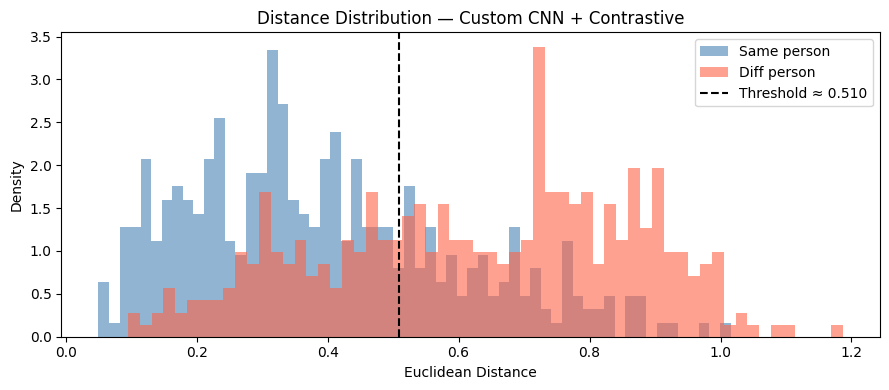

[Custom CNN + Contrastive] Threshold=0.5096  Accuracy=70.26%


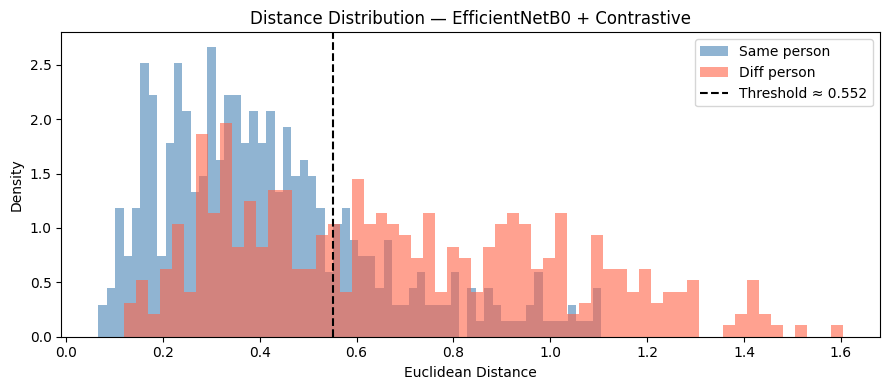

[EfficientNetB0 + Contrastive] Threshold=0.5519  Accuracy=68.21%


In [18]:
def plot_distance_distribution(model, img_A, img_B, labels, title=''):
    """
    Plots overlapping histograms of Euclidean distances for same vs. different pairs.
    A well-trained model will show near-zero overlap.
    """
    preds = model.predict([img_A, img_B], batch_size=64, verbose=0).flatten()
    same_dists = preds[labels == 1]
    diff_dists = preds[labels == 0]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(same_dists, bins=60, alpha=0.6, color='steelblue', label='Same person',  density=True)
    ax.hist(diff_dists, bins=60, alpha=0.6, color='tomato',    label='Diff person',  density=True)

    # Optimal threshold = midpoint of means
    thresh = (same_dists.mean() + diff_dists.mean()) / 2
    ax.axvline(thresh, color='black', linestyle='--', label=f'Threshold ≈ {thresh:.3f}')
    ax.set_xlabel('Euclidean Distance'); ax.set_ylabel('Density')
    ax.set_title(f'Distance Distribution — {title}')
    ax.legend(); plt.tight_layout(); plt.show()

    # Quick accuracy at this threshold
    preds_bin = (preds < thresh).astype(float)
    acc = np.mean(preds_bin == labels)
    print(f"[{title}] Threshold={thresh:.4f}  Accuracy={acc*100:.2f}%")
    return acc

print("=== Validation Set Distance Distributions ===")
acc_cnn_c = plot_distance_distribution(siamese_cnn_contrastive, val_A, val_B,
                                        val_labels, 'Custom CNN + Contrastive')
acc_eff_c = plot_distance_distribution(siamese_eff_contrastive, val_A, val_B,
                                        val_labels, 'EfficientNetB0 + Contrastive')

# ROC Curve & AUC

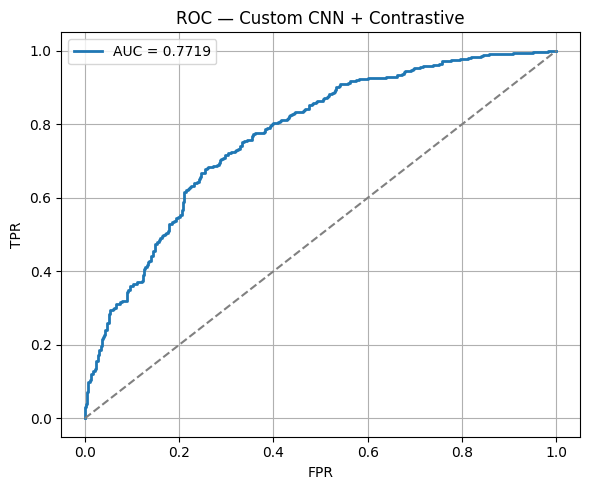

[Custom CNN + Contrastive] AUC-ROC = 0.7719


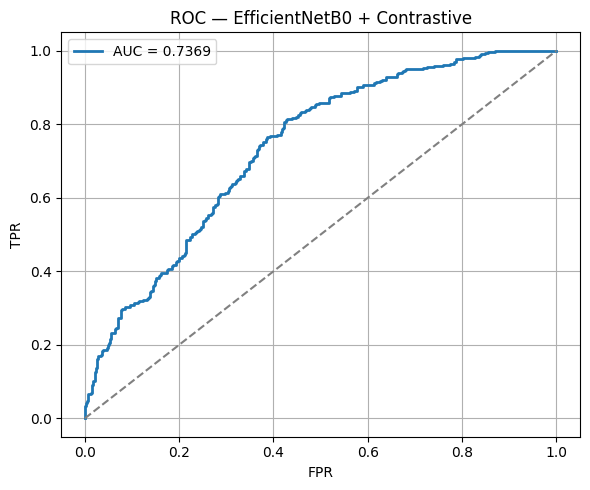

[EfficientNetB0 + Contrastive] AUC-ROC = 0.7369


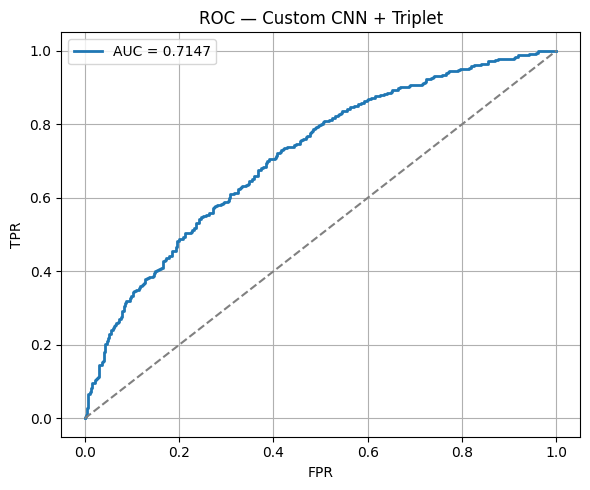

[Custom CNN + Triplet] AUC-ROC = 0.7147


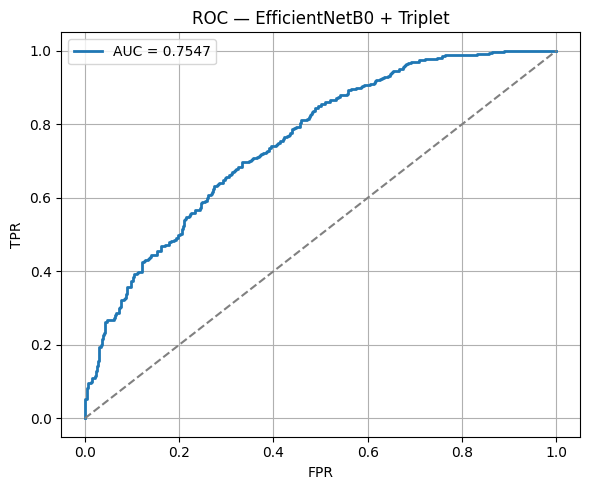

[EfficientNetB0 + Triplet] AUC-ROC = 0.7547


In [19]:
def plot_roc(model, img_A, img_B, labels, title='', is_triplet=False, backbone=None):
    """
    For verification tasks, AUC-ROC is the gold-standard metric because it is
    threshold-independent, unlike accuracy.
    """
    if is_triplet:
        # For triplet model, extract embeddings and compute distances manually
        embs_A = backbone.predict(img_A, batch_size=64, verbose=0)
        embs_B = backbone.predict(img_B, batch_size=64, verbose=0)
        dists = np.linalg.norm(embs_A - embs_B, axis=1)
    else:
        dists = model.predict([img_A, img_B], batch_size=64, verbose=0).flatten()

    # For ROC: similarity = 1 - normalized_distance
    scores = 1.0 / (1.0 + dists)
    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0,1],[0,1],'--',color='grey')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'ROC — {title}'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()
    print(f"[{title}] AUC-ROC = {auc:.4f}")
    return auc

auc_cnn_c = plot_roc(siamese_cnn_contrastive, val_A, val_B, val_labels,
                      'Custom CNN + Contrastive')
auc_eff_c = plot_roc(siamese_eff_contrastive, val_A, val_B, val_labels,
                      'EfficientNetB0 + Contrastive')
auc_cnn_t = plot_roc(None, val_A, val_B, val_labels,
                      'Custom CNN + Triplet', is_triplet=True, backbone=backbone_cnn_t)
auc_eff_t = plot_roc(None, val_A, val_B, val_labels,
                      'EfficientNetB0 + Triplet', is_triplet=True, backbone=backbone_eff_t)

# Summary Comparison Table

In [20]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Custom CNN', 'Custom CNN', 'EfficientNetB0', 'EfficientNetB0'],
    'Loss':  ['Contrastive', 'Triplet', 'Contrastive', 'Triplet'],
    'Val Accuracy (%)': [acc_cnn_c*100,
                          None,          # computed below
                          acc_eff_c*100,
                          None],
    'AUC-ROC': [auc_cnn_c, auc_cnn_t, auc_eff_c, auc_eff_t]
})

# Compute triplet val accuracy via distance threshold
def triplet_val_acc(backbone, img_A, img_B, labels):
    e_A = backbone.predict(img_A, batch_size=64, verbose=0)
    e_B = backbone.predict(img_B, batch_size=64, verbose=0)
    dists = np.linalg.norm(e_A - e_B, axis=1)
    thresh = (dists[labels==1].mean() + dists[labels==0].mean()) / 2
    return np.mean((dists < thresh).astype(float) == labels)

results.loc[1, 'Val Accuracy (%)'] = triplet_val_acc(backbone_cnn_t, val_A, val_B, val_labels) * 100
results.loc[3, 'Val Accuracy (%)'] = triplet_val_acc(backbone_eff_t, val_A, val_B, val_labels) * 100
results['Val Accuracy (%)'] = results['Val Accuracy (%)'].map('{:.2f}'.format)
results['AUC-ROC'] = results['AUC-ROC'].map('{:.4f}'.format)

print("\n" + "="*55)
print("          FINAL RESULTS COMPARISON")
print("="*55)
print(results.to_string(index=False))


          FINAL RESULTS COMPARISON
         Model        Loss Val Accuracy (%) AUC-ROC
    Custom CNN Contrastive            70.26  0.7719
    Custom CNN     Triplet            64.87  0.7147
EfficientNetB0 Contrastive            68.21  0.7369
EfficientNetB0     Triplet            67.82  0.7547


# Inference Pipeline

Testing SAME person: Edmund_Stoiber


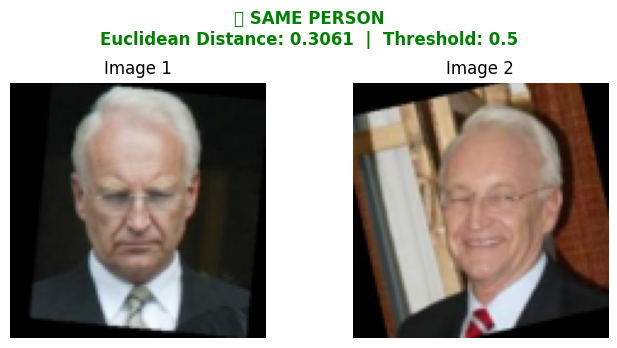

{'distance': 0.30607956647872925, 'decision': '✅ SAME PERSON'}

Testing DIFFERENT: John_Bolton vs Hans_Blix


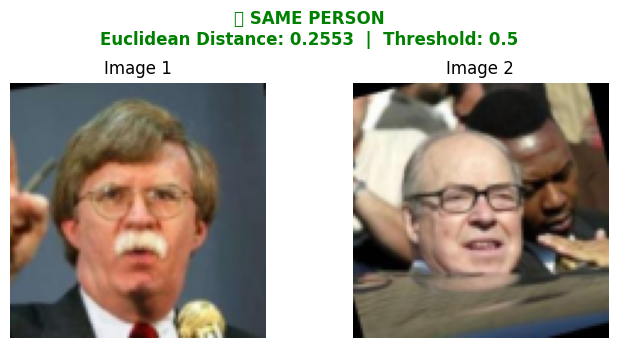

{'distance': 0.255264550447464, 'decision': '✅ SAME PERSON'}


In [21]:
def verify_faces(img_path_1: str, img_path_2: str,
                 model, backbone=None,
                 threshold: float = 0.5,
                 is_triplet_backbone: bool = False):
    """
    Takes two image paths, returns:
      - Euclidean distance
      - Similarity decision (Same / Different)
      - Visual display of the pair with decision overlay
    """
    img1 = load_image(img_path_1)
    img2 = load_image(img_path_2)

    if is_triplet_backbone:
        e1 = backbone.predict(img1[np.newaxis], verbose=0)[0]
        e2 = backbone.predict(img2[np.newaxis], verbose=0)[0]
        distance = float(np.linalg.norm(e1 - e2))
    else:
        distance = float(model.predict(
            [img1[np.newaxis], img2[np.newaxis]], verbose=0)[0][0])

    decision = "✅ SAME PERSON" if distance < threshold else "❌ DIFFERENT PERSON"

    # ── Visualisation ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    axes[0].imshow(img1); axes[0].set_title('Image 1'); axes[0].axis('off')
    axes[1].imshow(img2); axes[1].set_title('Image 2'); axes[1].axis('off')

    colour = 'green' if distance < threshold else 'red'
    fig.suptitle(f'{decision}\nEuclidean Distance: {distance:.4f}  |  Threshold: {threshold}',
                 fontsize=12, color=colour, fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'distance': distance, 'decision': decision}


# ── Demo: pick two images from validation set ─────────────────────────────────
# Same-person test
person_demo = random.choice(val_persons)
img1_path, img2_path = random.sample(filtered[person_demo], 2)
print(f"Testing SAME person: {person_demo}")
result = verify_faces(img1_path, img2_path,
                       model=siamese_eff_contrastive, threshold=0.5)
print(result)

# Different-person test
p1, p2 = random.sample(val_persons, 2)
img1_path = random.choice(filtered[p1])
img2_path = random.choice(filtered[p2])
print(f"\nTesting DIFFERENT: {p1} vs {p2}")
result = verify_faces(img1_path, img2_path,
                       model=siamese_eff_contrastive, threshold=0.5)
print(result)

# Calibrate Optimal Threshold per Model

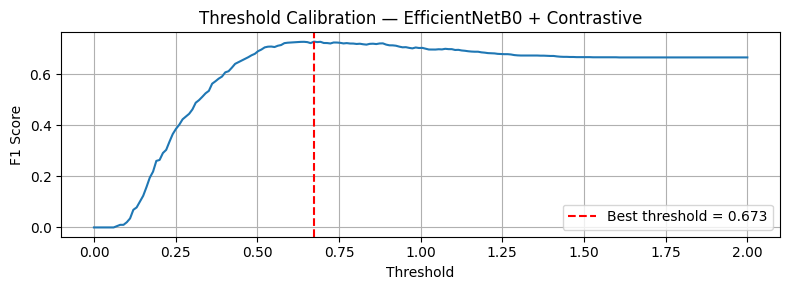

[EfficientNetB0 + Contrastive] Optimal threshold = 0.6734  |  F1 = 0.7286


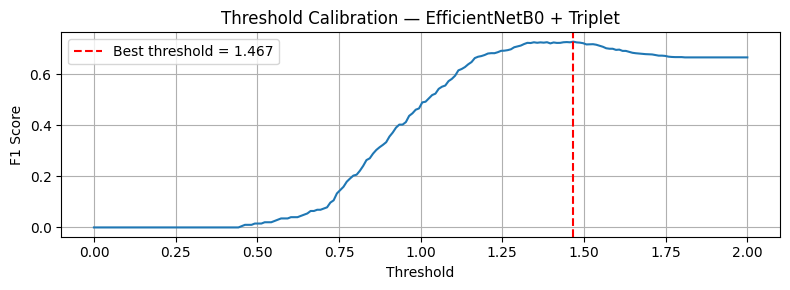

[EfficientNetB0 + Triplet] Optimal threshold = 1.4673  |  F1 = 0.7285


In [22]:
def find_optimal_threshold(model, img_A, img_B, labels,
                             backbone=None, is_triplet=False,
                             title=''):
    """
    Sweep thresholds to find the one maximising F1 (harmonic mean of precision & recall).
    This is more useful than accuracy when you care about false-accept vs. false-reject tradeoff.
    """
    from sklearn.metrics import f1_score

    if is_triplet:
        e_A = backbone.predict(img_A, batch_size=64, verbose=0)
        e_B = backbone.predict(img_B, batch_size=64, verbose=0)
        dists = np.linalg.norm(e_A - e_B, axis=1)
    else:
        dists = model.predict([img_A, img_B], batch_size=64, verbose=0).flatten()

    thresholds = np.linspace(0.0, 2.0, 200)
    f1s = [f1_score(labels, (dists < t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]

    plt.figure(figsize=(8,3))
    plt.plot(thresholds, f1s)
    plt.axvline(best_t, color='red', linestyle='--', label=f'Best threshold = {best_t:.3f}')
    plt.xlabel('Threshold'); plt.ylabel('F1 Score')
    plt.title(f'Threshold Calibration — {title}')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    print(f"[{title}] Optimal threshold = {best_t:.4f}  |  F1 = {max(f1s):.4f}")
    return best_t

best_t_eff_c = find_optimal_threshold(siamese_eff_contrastive, val_A, val_B, val_labels,
                                        title='EfficientNetB0 + Contrastive')
best_t_eff_t = find_optimal_threshold(None, val_A, val_B, val_labels,
                                        backbone=backbone_eff_t, is_triplet=True,
                                        title='EfficientNetB0 + Triplet')